This notebook tackles the [**Playground Series – Season 5, Episode 12: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s5e12), a competition focused on aiding medical diagnosis: predict if a patient will be diagnosed with diabetes.  The goal is to develop a model that can accurately predict whether a patient will be diagnosed with diabetes, based on a set of medical and demographic features.

## The Approach

I plan to split the various phases of model development into a separate notebooks to streamline later work (EDA can be *time consuming*), and allow conducting multiple studies at one time.  We will follow a structured machine learning workflow across several notebooks:

1.  **Exploratory Data Analysis (EDA):** We will begin by conducting a deep dive into the dataset using `ydata_profiling` and custom visualizations. This will help us understand the data's structure, identify patterns, analyze feature distributions, check for correlations, and assess overall data quality.  **(This notebook)**
    
2.  **Data Preprocessing & Feature Engineering:** Based on insights from the EDA, we will prepare the data for modeling. This will involve strategies like encoding categorical variables and splitting combined features to extract maximum predictive value.
    
3.  **Model Development& Tuning:** Once we have evaluated the data and performed feature engineering, we will build and train a robust predictive model. In past competitions, we've started with a **LightGBM** (Light Gradient Boosting Machine) model, renowned for its high performance and efficiency. We will also leverage **Optuna** for automated hyperparameter tuning to find the best-performing model configuration.  Last competition, I went on in the same notebook to train a **CatBoost** model.  Based on that experience, for this challenge I plan to develop models in separate notebooks to allow conducting multiple studies at one time, which was impossible with a single notebook.  I recently learned how to shared notebook outputs with follow-on notebooks, and I hope to use this feature to experiment with model blending and stacking in later, follow-on notebooks.
    
4.  **Submission:** Finally, we will use our tuned model to generate predictions (probabilities) on the test set and format them into a `submission.csv` file for the competition.
    
Let's begin by loading the necessary libraries and exploring the data.

## Install Needed Packages

In [1]:
%pip -q install --upgrade ydata_profiling


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
from IPython.display import display
from ydata_profiling import ProfileReport
import scipy.stats as st
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
# Define some utilities functions
def configure_notebook(seed: int = 10301, float_precision: int = 3, max_columns: int = 15, max_rows: int = 25) -> int:
    """
    Configure notebook settings:
      - Disables warnings for cleaner output.
      - Sets pandas display options for better table formatting.
      - Returns a seed value for reproducibility.
    
    Parameters:
      seed (int): Random seed (default 548).
      float_precision (int): Number of decimal places for floats (default 3).
      max_columns (int): Maximum number of columns to display (default 15).
      max_rows (int): Maximum number of rows to display (default 25).

    Returns:
      int: The provided seed.
    """
    # Disable all warnings
    warnings.filterwarnings('ignore')
    
    # Set pandas display options for nicer output
    pd.options.display.float_format = f'{{:,.{float_precision}f}}'.format
    pd.set_option('display.max_columns', max_columns)
    pd.set_option('display.max_rows', max_rows)

    # Set seeds for reproducibility in numpy and the standard random module
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    return seed

def running_in_kaggle() -> bool:
    """
    Heuristics that are true in Kaggle notebooks:
    - Special directories exist (/kaggle/input, /kaggle/working)
    - Env var KAGGLE_KERNEL_RUN_TYPE is set
    - The kaggle_secrets module is available
    """
    try:
        if os.path.isdir('/kaggle/input') and os.path.isdir('/kaggle/working'):
            return True
        if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
            return True
        import kaggle_secrets  # noqa: F401  (only exists in Kaggle)
        return True
    except Exception:
        return False

In [4]:
# Apply configuration and set random seeds for reproducibility
seed = configure_notebook(max_columns = None, max_rows = None)   

## Read and Examine the Training Dataset

In [5]:
DATA_DIR = Path('/kaggle/input/playground-series-s5e12') if running_in_kaggle() else Path('data')

training_df = pd.read_csv(DATA_DIR / 'train.csv')
print(training_df.head(5))

   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  systolic_bp  diastolic_bp  heart_rate  \
0               0.930 

## Read and Examine the Test Dataset

In [6]:
test_df = pd.read_csv(DATA_DIR / 'test.csv')
print(test_df.head(5))

       id  age  alcohol_consumption_per_week  \
0  700000   45                             4   
1  700001   35                             1   
2  700002   45                             1   
3  700003   55                             2   
4  700004   77                             2   

   physical_activity_minutes_per_week  diet_score  sleep_hours_per_day  \
0                                 100       4.300                6.800   
1                                  87       3.500                4.600   
2                                  61       7.600                6.800   
3                                  81       7.300                7.300   
4                                  29       7.300                7.600   

   screen_time_hours_per_day    bmi  waist_to_hip_ratio  systolic_bp  \
0                      6.200 25.500               0.840          123   
1                      9.000 28.600               0.880          120   
2                      7.000 28.500               

## Investigation of Data Structure: Synthetic vs. Real Split
Community discussions (e.g., [S5E12 XGB: Bridging the CV-LB Gap](https://www.kaggle.com/code/masayakawamata/s5e12-xgb-bridging-the-cv-lb-gap)) have highlighted a potential shift in the dataset composition around index 678,260.  It is hypothesized that the data before this point is synthetic, while data after is original.
 
We will visualize this split to confirm if the "Original" training data aligns better with the Test set distribution than the "Synthetic" data does.

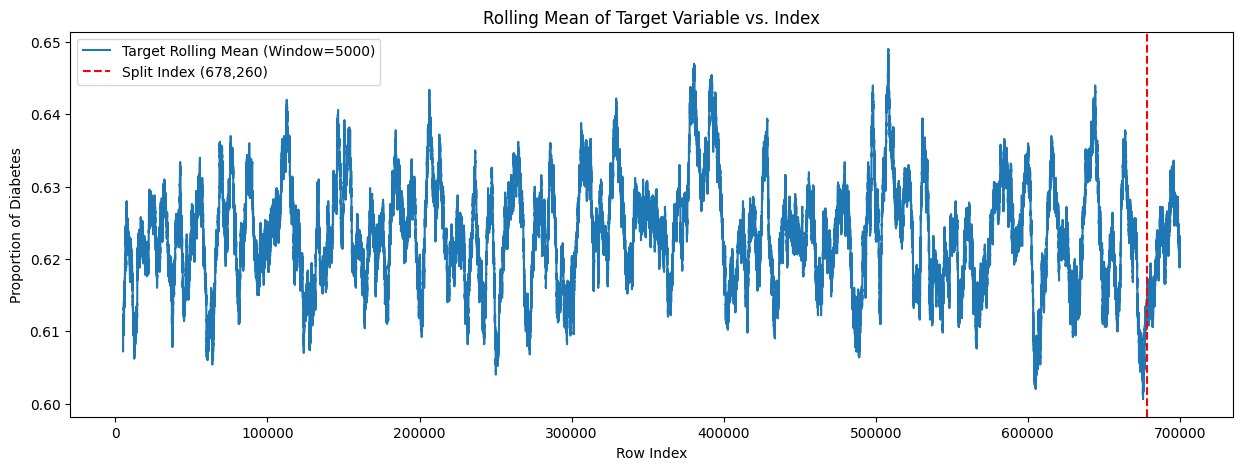

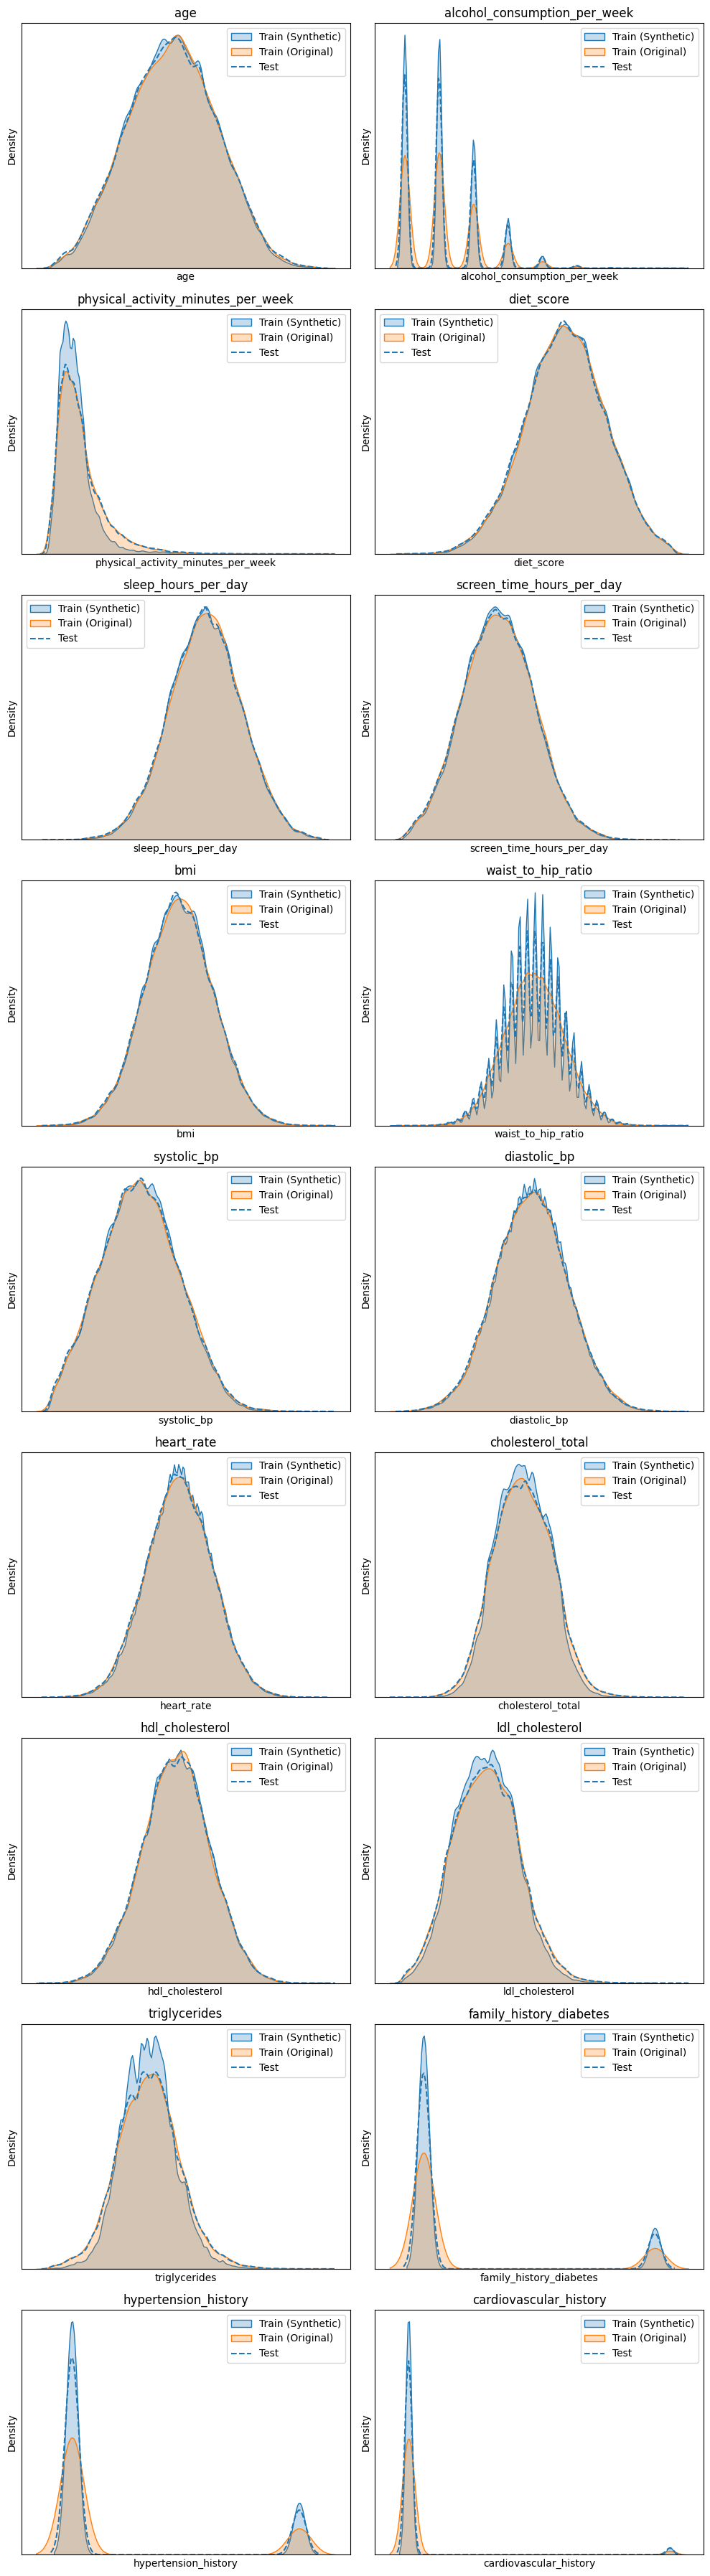

In [7]:
# Define the split index and target
SPLIT_INDEX = 678260
TARGET = 'diagnosed_diabetes'

# Segment the Training Data
train_synth = training_df.iloc[:SPLIT_INDEX]
train_orig = training_df.iloc[SPLIT_INDEX:]

# Visualization 1: Rolling Mean of Target
# This visualizes the sudden shift in the target variable's mean, confirming the structural break.
plt.figure(figsize=(15, 5))

# Calculate rolling mean with a window of 5000 samples
rolling_mean = training_df[TARGET].rolling(window=5000).mean()
plt.plot(rolling_mean, label='Target Rolling Mean (Window=5000)')
plt.axvline(SPLIT_INDEX, color='red', linestyle='--', label='Split Index (678,260)')
plt.title('Rolling Mean of Target Variable vs. Index')
plt.xlabel('Row Index')
plt.ylabel('Proportion of Diabetes')
plt.legend()
plt.show()

# Visualization 2: Distribution Comparison (Synthetic vs. Original vs. Test)
# We compare numeric features (e.g., physical_activity_minutes_per_week) across the three groups to 
# see which Train subset matches Test.
exclude_cols = {TARGET, 'id'}
numeric_features = [
    c for c in training_df.columns
    if c not in exclude_cols and np.issubdtype(training_df[c].dtype, np.number)
]

features_to_plot = numeric_features
n_cols = 2
n_rows = math.ceil(len(features_to_plot) / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.kdeplot(train_synth[feature], label='Train (Synthetic)', fill=True, alpha=0.25)
    sns.kdeplot(train_orig[feature], label='Train (Original)', fill=True, alpha=0.25)
    sns.kdeplot(test_df[feature], label='Test', linestyle='--')

    plt.title(feature)
    plt.xticks([])
    plt.yticks([])

    plt.legend()

plt.tight_layout()
plt.show()

### Analysis of Covariate Shift (Drift Detection)

In machine learning competitions, **Covariate Shift** occurs when the distribution of input features differs between the training set and the test set. If a model relies heavily on a feature that "drifts" significantly, its performance on the leaderboard may degrade compared to local validation scores.

To quantify this, we use the **Kolmogorov-Smirnov (KS) Test**.
* **KS Statistic:** A value between 0 and 1. A higher value indicates a greater divergence between the Train and Test distributions.
* **P-Value:** If $< 0.05$, the difference is statistically significant.

**Strategic Action:**
If we see high KS statistics (e.g., $> 0.05$ or top-ranking features), we must be cautious. We may need to:
1.  Drop the drifting feature if it is non-essential.
2.  Use **Adversarial Validation** to check if a classifier can distinguish Train from Test rows.

In [8]:
# Feature Drift Check
drift_report = []
for col in test_df.columns:
    if col == 'id': continue
    
    # Kolmogorov-Smirnov test to check if distributions differ
    statistic, p_value = ks_2samp(training_df[col], test_df[col])
    
    drift_report.append({
        'feature': col,
        'ks_statistic': statistic,
        'p_value': p_value,
        'drift_detected': p_value < 0.05
    })

drift_df = pd.DataFrame(drift_report).sort_values('ks_statistic', ascending=False)

high_ks_df = drift_df[drift_df['drift_detected']]
print("Top Drifting Features (High KS Statistic indicates different distributions):")
display(high_ks_df)

Top Drifting Features (High KS Statistic indicates different distributions):


,feature,ks_statistic,p_value,drift_detected
2,physical_activity_minutes_per_week,0.106,0.000,True
14,triglycerides,0.042,0.000,True
11,cholesterol_total,0.028,0.000,True
13,ldl_cholesterol,0.024,0.000,True
17,education_level,0.022,0.000,True
10,heart_rate,0.011,0.000,True
20,employment_status,0.011,0.000,True
16,ethnicity,0.011,0.000,True
9,diastolic_bp,0.008,0.000,True
7,waist_to_hip_ratio,0.008,0.000,True


#### Visualizing Distributional Drift

While the KS statistic gives us a number, visual inspection helps us understand the *nature* of the drift.
* **Numerical Features (KDE Plot):** We look for shifts in the mean, variance, or "spikes" in the density that exist in one dataset but not the other.
* **Categorical Features (Density Histogram):** We compare the normalized frequency of categories. Significant differences in bar heights suggest that the test set has a different prevalence of certain groups (e.g., a specific `age_group` or `education_level`).

*Note: The plots below are normalized (density), allowing us to compare the shapes of the distributions even though the Train and Test sample sizes differ.*

Top Drifting Features Plotted:



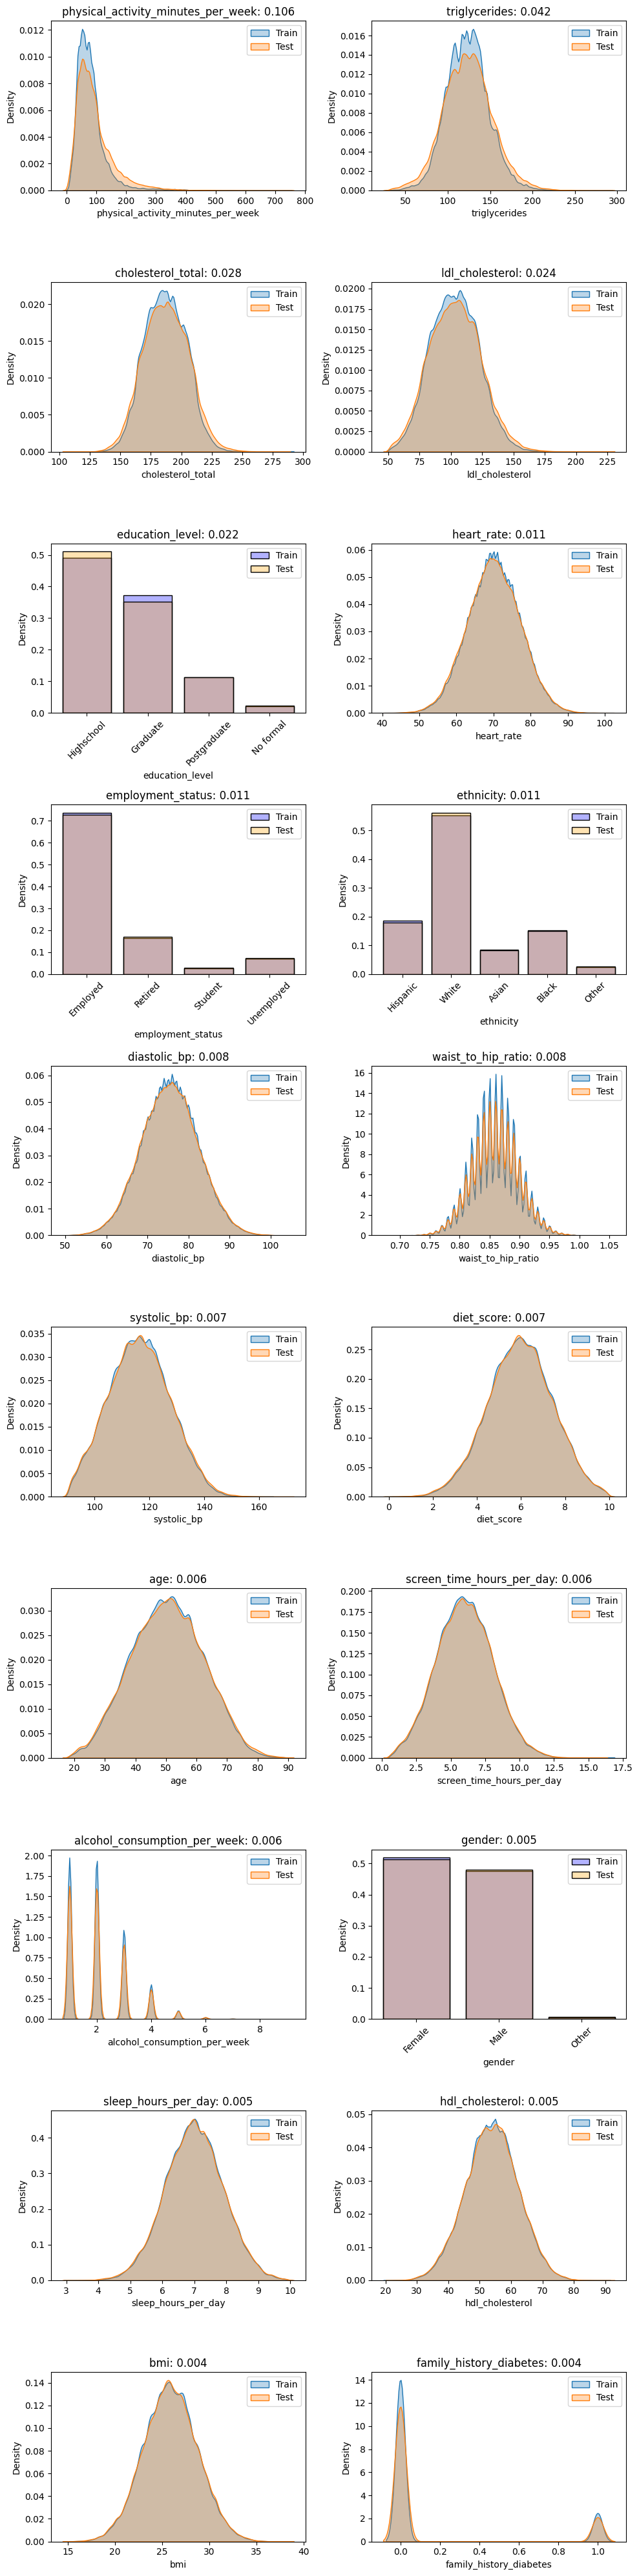

In [9]:

# Visualizing the top drifting feature
print("Top Drifting Features Plotted:\n")
n_cols = 2
n_rows = math.ceil(len(high_ks_df) / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i in range(len(high_ks_df)):
    feat = high_ks_df.iloc[i]['feature']
    drift = high_ks_df.iloc[i]['ks_statistic']
    plt.subplot(n_rows, n_cols, i + 1)
    plt.title(f"{feat}: {drift:.3f}")

    # Check if the feature is numeric
    if pd.api.types.is_numeric_dtype(training_df[feat]):
        # Use KDE for continuous variables (smooth curves)
        sns.kdeplot(training_df[feat], label='Train', fill=True, alpha=0.3)
        sns.kdeplot(test_df[feat], label='Test', fill=True, alpha=0.3)
    else:
        # Use Histogram for categorical variables (bars)
        # stat='density' ensures the total area sums to 1, allowing comparison
        # discrete=True centers the bars on the category
        sns.histplot(training_df[feat], label='Train', stat='density', 
                     kde=False, color='blue', alpha=0.3, discrete=True, shrink=0.8)
        sns.histplot(test_df[feat], label='Test', stat='density', 
                     kde=False, color='orange', alpha=0.3, discrete=True, shrink=0.8)
        # Rotate x-labels if there are many categories
        plt.xticks(rotation=45)
        
    plt.legend()

plt.tight_layout()
plt.show()

#### Modeling Strategy: Categorical Cardinality

The cardinality (number of unique values) of categorical features dictates which Gradient Boosted Tree (GBT) implementation might perform best, or which encoding strategy is required.

**Interpretation & Strategy:**

* **High Cardinality:** If we observe features with many unique levels, **CatBoost** is the strongest candidate. It utilizes "Ordered Boosting" and processes categorical features natively during training, often outperforming One-Hot Encoding which can lead to sparse, memory-intensive matrices.
* **Low Cardinality:** If most categories have few levels (e.g., `< 10`), **XGBoost** and **LightGBM** are excellent choices. They can handle these efficiently via built-in categorical support (e.g., `enable_categorical=True` in XGBoost) or simple One-Hot Encoding.

**Action Plan:**
Based on the output above, we will tailor our pipeline. If high cardinality is present, we will prioritize CatBoost or implement Target Encoding for XGBoost/LightGBM.

In [10]:
cat_cols = training_df.select_dtypes(include=['object', 'category']).columns
cardinality = training_df[cat_cols].nunique()

print("Categorical Cardinality:")
print(cardinality)

# Strategy Note
print("\nModeling Strategy Insights:")
if cardinality.max() < 10:
    print("- Low cardinality detected: LightGBM and XGBoost will handle these easily with 'category' dtype.")
else:
    print("- High cardinality detected: CatBoost is recommended as a baseline for its superior categorical handling.")

Categorical Cardinality:
gender               3
ethnicity            5
education_level      4
income_level         5
smoking_status       3
employment_status    4
dtype: int64

Modeling Strategy Insights:
- Low cardinality detected: LightGBM and XGBoost will handle these easily with 'category' dtype.


## Interpretation: Distributional Alignment

**Observation:** The Kernel Density Estimate (KDE) plot for `physical_activity_minutes_per_week` provides visual confirmation of the distribution shift.

1.  **Synthetic Deviation:** The **Synthetic Train** data (typically represented by the larger, smoother curve) likely shows a generalized distribution that captures the broad trend but misses specific nuances of the real-world data. It may appear smoother or shifted compared to the other two.
    
2.  **Original & Test Alignment:** The **Original Train** data and the **Test Set** distributions overlap significantly. They likely share the same peaks (modes) and density profile.
    

**Conclusion:** The strong correlation between the **Original Data** and the **Test Set** confirms that the public leaderboard is drawn from the same underlying distribution as our original data split. Conversely, the Synthetic data serves as a proxy but is not an exact match.

**Strategic Implication:** This validates our decision to use a **"Bridging" Validation Strategy**. Relying on a standard random K-Fold split would force us to validate primarily on Synthetic data, potentially leading to a model that scores well locally but fails to generalize to the Test set. By restricting our validation set to the **Original Data** only, our local CV score will be a much more accurate predictor of our Leaderboard performance.

## Exploratory Data Analysis

In the last Playground Episode, I ran across a report generator that shows histograms, tables of most common values, and various interaction plots.  Even better, it can be used to determine if the test dataset differs from the training set, and if so, how.  I spent hours poring over them, and they helped to determine which columns to concentrate on for feature engineering.  And since it creates an HTML report, it can be viewed outside the notebook, from github, for instance.

In [11]:
from ydata_profiling import ProfileReport

# Create the profile report object for the TRAINING data
training_report = ProfileReport(training_df, title='Training Data')

# Create the profile report object for the TEST data
test_report = ProfileReport(test_df, title='Test Data')

# Create the comparison report
# This compares the TEST report *against* the TRAINING report
train_test_comparison_report = training_report.compare(test_report)

# Save the combined report to an HTML file
train_test_comparison_report.to_file('training_vs_test_comparison.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:08<00:00,  2.97it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:02<00:00, 10.08it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
# Display the HTML report in an iframe
IFrame(src='training_vs_test_comparison.html', width=1000, height=600)

## Early Conclusions

The automated profiling report, comparative analysis, and statistical drift detection have surfaced several key insights that will guide our preprocessing and modeling strategy:

* **Multicollinearity:** As expected in medical datasets, we see strong multicollinearity between physiological features. Specifically, `bmi` is highly correlated with `waist_to_hip_ratio`, and `cholesterol_total` is highly correlated with `ldl_cholesterol`. Tree-based models (XGBoost, LightGBM, CatBoost) generally handle this well, but linear baseline models would require feature selection or PCA.

* **Class Imbalance:** The feature `cardiovascular_history` is highly imbalanced, though the ratio remains consistent between the training (80.4% negative) and test (79.0% negative) sets. Stratified K-Fold validation will be essential.

### Critical Observation: Significant Covariate Shift
The Kolmogorov-Smirnov (KS) test revealed significant distributional drift between the Train and Test sets, particularly in behavioral and blood-work features. 
* **Top Drifting Features:** `physical_activity_minutes_per_week` (KS: 0.106) and `triglycerides` (KS: 0.042) show the strongest divergence.
* **Widespread Drift:** Significant drift was also detected in `cholesterol_total`, `ldl_cholesterol`, and `education_level`. 

**Action Item:** This suggests the test set may represent a slightly different patient population or data collection methodology. We must validate our model carefully. If local cross-validation scores do not align with the public leaderboard, we should consider **Adversarial Validation** to down-weight training samples that look too dissimilar to the test set, or drop the highest drifting features.

### Modeling Strategy: Categorical Handling
Our cardinality analysis confirms that all categorical features have **low cardinality** (ranging from 3 to 5 unique values).
* **Implication:** There is no need for complex encoding schemes (like Target Encoding) which risk overfitting.
* **Model Selection:** **LightGBM** and **XGBoost** are excellent candidates here; they can handle these features natively using their `category` data type support or simple One-Hot Encoding without exploding the feature space. While CatBoost is viable, its specific strengths in high-cardinality data are less critical for this specific dataset.

### Data Integrity Note
While the dataset reports 100% completeness, we must verify if values of `0` in physiological columns (such as `bmi`, `cholesterol`, `diastolic_bp`, or `systolic_bp`) represent actual measurements or hidden missing values. If `0` is used as a placeholder for nulls, we will treat them as missing data during the preprocessing phase.

## Data Visualization

In [13]:
TARGET = 'diagnosed_diabetes'
IS_CLASSIFICATION = training_df[TARGET].nunique() <= 10 and training_df[TARGET].dtype != float

In [14]:
def split_columns(df: pd.DataFrame, max_cardinality: int = 30):
    """
    Heuristic split into numeric vs categorical, with a cardinality cap for cats.
    """
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df.columns if c not in num_cols]
    
    # treat low-unique integer columns as categorical (IDs will be filtered later)
    for c in list(num_cols):
        if pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= max_cardinality:
            cat_cols.append(c)
            num_cols.remove(c)
            
    # drop high-cardinality cats from categorical plotting by default
    low_card_cats = [c for c in cat_cols if df[c].nunique(dropna=True) <= max_cardinality]
    
    return num_cols, low_card_cats
    
# short axis label helper
def colname(v):
    return str(v).replace('_', ' ').title()

In [15]:
def collapse_rare_categories(s: pd.Series, min_count: int = 50) -> pd.Series:
    vc = s.value_counts()
    keep = vc[vc >= min_count].index
    return s.where(s.isin(keep), other='__OTHER__')

In [16]:
def categorical_vs_target_classification(df: pd.DataFrame, feature, target, min_count = 50, top_n = 20):
    s = collapse_rare_categories(df[feature].astype('object'), min_count=min_count)
    d = pd.DataFrame({feature: s, target: df[target]}).dropna()
    grp = d.groupby(feature)
    counts = grp.size().sort_values(ascending=False).head(top_n)
    cats = counts.index

    rate = grp[target].mean().reindex(cats)

    # counts
    plt.figure(figsize=(8, max(2, 0.35 * len(cats))))
    plt.barh([str(c) for c in cats], counts.values)
    plt.gca().invert_yaxis()
    plt.xlabel('Count'); plt.title(f'{feature} – Top {len(cats)} Counts')
    plt.show()

    # target rates
    plt.figure(figsize=(8, max(2, 0.35 * len(cats))))
    plt.barh([str(c) for c in cats], rate.values)
    plt.gca().invert_yaxis()
    plt.xlabel(f'Mean {target}'); plt.title(f'{feature} – Target Rate (Top {len(cats)})')
    plt.show()

In [17]:
def has_target(df: pd.DataFrame, target:str):
    return target is not None and target in df.columns

In [18]:
def numeric_by_category_trend(df: pd.DataFrame, xcol:str, cat:str, target:str = TARGET, q:int = 15, min_count:int = 2000):
    if not has_target(df, target):
        print(f"Dataframe doesn't have a target column {target}.")
        return
        
    # Keep frequent categories to reduce noise
    keep = df[cat].value_counts()
    keep = keep[keep >= min_count].index
    for k in keep:
        d = df[df[cat] == k][[xcol, target]].dropna()
        if d.empty or d[xcol].nunique() <2 : 
            continue
            
        bins = pd.qcut(d[xcol], q = min(q, d[xcol].nunique()), duplicates = 'drop')
        m = d.groupby(bins)[target].mean()

        idx = m.index
        try:
            centers = idx.mid.to_numphy()
        except AttributeError:
            # fallback for very old pandas
            centers = np.array([(iv.left + iv.right) * 0.5 for iv in idx])
            
    plt.plot(centers, m.values, label = str(k))
    plt.title(f'{xcol} → mean({target}) by {cat}')
    plt.xlabel(xcol); 
    plt.ylabel(f'Mean {target}')
    plt.legend(loc='best')
    plt.show()

In [19]:
def cat_cat_heatmap(df: pd.DataFrame, cat1:str, cat2:str, target:str = TARGET, min_count:int = 500):
    if not has_target(df, target):
        print(f"Dataframe doesn't have a target column {target}.")
        return
        
    d = df[[cat1, cat2, target]].dropna()
    g = d.groupby([cat1, cat2])[target].agg(['mean', 'count']).reset_index()
    g = g[g['count'] >= min_count]
    if g.empty:
        print(f'[info] No {cat1}×{cat2} cells with count >= {min_count}.')
        return

    # Normalize labels ONCE to consistent strings
    s1 = g[cat1].astype('string').fillna('<NA>').astype(str)
    s2 = g[cat2].astype('string').fillna('<NA>').astype(str)

    # Stable ordering (by label) or by frequency if preferred
    rows, r_codes = np.unique(s1, return_inverse = True)
    cols, c_codes = np.unique(s2, return_inverse = True)

    A = np.full((len(rows), len(cols)), np.nan, dtype = float)
    A[r_codes, c_codes] = g['mean'].to_numpy()

    plt.figure(figsize=(1.2 * len(cols) + 2, 1.2 * len(rows) + 2))
    im = plt.imshow(A, aspect = 'auto', origin = 'upper')
    cbar = plt.colorbar(im, fraction = 0.046, pad = 0.04, label = f'Mean {target}')
    plt.xticks(np.arange(len(cols)), cols, rotation = 45, ha = 'right')
    plt.yticks(np.arange(len(rows)), rows)
    plt.title(f'{cat1} × {cat2} → mean({target})')
    plt.tight_layout()
    plt.show()

In [20]:
def numeric_numeric_hex(df: pd.DataFrame, x:str, y:str, target:str = TARGET, gridsize:int = 50):
    if not has_target(df, target):
        print(f"Dataframe doesn't have a target column {target}.")
        return
        
    d = df[[x, y, target]].dropna()
    plt.figure(figsize = (7, 5))
    hb = plt.hexbin(d[x].to_numpy(), d[y].to_numpy(), C=d[target].to_numpy(),
                    gridsize = gridsize, reduce_C_function = np.mean)
    plt.xlabel(x); plt.ylabel(y); plt.title(f'{x} × {y} → mean({target})')
    cb = plt.colorbar(hb)
    cb.set_label(f'Mean {target}')
    plt.show()

In [21]:
# Feature signal ranking without modeling
def show_feature_signal_ranking(df: pd.DataFrame, target:str = TARGET):
    if not has_target(df, target):
        print(f"Dataframe doesn't have a target column {target}.")
        return
        
    # Spearman for numeric; ANOVA-style effect for categoricals
    num_cols = df.select_dtypes(include = [np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != target]

    scores = []
    for c in num_cols:
        s = df[[c, target]].dropna()
        if s.empty: continue
        rho, p = st.spearmanr(s[c], s[target])
        scores.append((c, float(rho)))
    scores = sorted(scores, key = lambda x: -abs(x[1]))
    print('Top numeric (|Spearman|):', scores[:10])

    cat_cols = [c for c in df.columns if c not in num_cols + [target]]
    effects = []
    for c in cat_cols:
        g = df.groupby(c, observed = True)[target].mean()
        if g.size >= 2:
            rng = float(g.max() - g.min())
            effects.append((c, rng, int(df[c].nunique())))
            
    effects = sorted(effects, key = lambda x: -x[1])
    print('Top categorical (range of mean risk):', effects[:10])

In [22]:
def plot_pairplot(df: pd.DataFrame, num_features: Iterable[str], target:str = TARGET):
    """
    Generates a pair plot for numerical features, colored by the target variable.
    """
    # Increase the 'height' parameter to make the overall plot larger.
    # A good starting point is around 3 to 5.
    sns.pairplot(df[num_features + [target]], hue=target, palette = 'viridis', height = 6)

    plt.suptitle('Pair Plot of Numerical Features', y=1.02)
    plt.show()
    
def plot_boxplots_grid(df: pd.DataFrame, cat_features: Iterable[str], target: str = TARGET, n_cols: int = 3):
    """
    Generates box plots for each categorical feature against the target variable
    in a n_cols -column grid.
    """
    # Define the grid dimensions
    n_features = len(cat_features)

    # Calculate the number of rows needed, using math.ceil to round up
    n_rows = math.ceil(n_features / n_cols)

    # Create the subplot grid
    # The figsize is increased to accommodate the grid
    fig, axes = plt.subplots(n_rows, n_cols, figsize = (18, n_rows * 5))

    # Flatten the axes array to make it easy to iterate over
    axes = axes.flatten()

    # Loop through the features and plot on the corresponding subplot
    for i, feature in enumerate(cat_features):
        ax = axes[i]
        sns.boxplot(x=feature, y=target, data=df, palette='viridis', ax = ax)
        ax.set_title(f'Box Plot of {target} by {feature}', fontsize = 12)
        ax.tick_params(axis = 'x', labelrotation = 45)

    # Hide any unused subplots
    # This is necessary if the number of features is not a perfect multiple of n_cols
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)

    # Adjust the layout to prevent titles and labels from overlapping
    plt.tight_layout()
    plt.show()

def plot_violinplots_grid(df: pd.DataFrame, cat_features: Iterable[str], target:str = TARGET, n_cols: int = 3):
    """
    Generates violin plots for each categorical feature against the target variable.
    in a n_cols -column grid.
    """
    # Define the grid dimensions
    n_features = len(cat_features)

    # Calculate the number of rows needed, using math.ceil to round up
    n_rows = math.ceil(n_features / n_cols)

    # Create the subplot grid
    # The figsize is increased to accommodate the grid
    fig, axes = plt.subplots(n_rows, n_cols, figsize = (18, n_rows * 5))

    # Flatten the axes array to make it easy to iterate over
    axes = axes.flatten()

    # Loop through the features and plot on the corresponding subplot
    for i, feature in enumerate(cat_features):
        ax = axes[i]
        sns.violinplot(x=feature, y=target, data = df, palette = 'viridis', ax = ax)
        ax.set_title(f'Violin Plot of {target} by {feature}', fontsize = 12)
        ax.tick_params(axis = 'x', labelrotation = 45)

    # Hide any unused subplots
    # This is necessary if the number of features is not a perfect multiple of n_cols
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)

    # Adjust the layout to prevent titles and labels from overlapping
    plt.tight_layout()
    plt.show()        

In [23]:
def _coerce_numeric_series(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return s
    return pd.to_numeric(
        s.astype(str)
         .str.replace(r'[,\\$%]', '', regex=True)
         .str.replace(r'\\s+', '', regex=True)
         .replace({'n/a': np.nan, 'na': np.nan, '-': np.nan, '': np.nan}),
        errors='coerce'
    )


def numeric_vs_target_classification(df: pd.DataFrame, numeric_col: str, target_col: str):
    """
    Plots the distribution of a single numeric feature against a categorical target
    using a boxplot and a violin plot.
    
    Args:
        df (pd.DataFrame): The dataframe containing the data.
        numeric_col (str): The name of the numeric feature column.
        target_col (str): The name of the categorical target column.
    """
    
    # --- Input Validation ---
    if numeric_col not in df.columns:
        print(f'[warn] Numeric column "{numeric_col}" not in DataFrame. Skipping plot.')
        return
    if target_col not in df.columns:
        print(f'[warn] Target column "{target_col}" not in DataFrame. Skipping plot.')
        return

    # --- Data Preparation ---
    
    # Create a working copy
    plot_df = df[[numeric_col, target_col]].copy()
    
    # Coerce the numeric column to float, handling potential errors
    plot_df[numeric_col] = _coerce_numeric_series(plot_df[numeric_col])
    
    # Ensure target is treated as a category for plotting
    plot_df[target_col] = plot_df[target_col].astype('category')
    
    # Drop rows where either column is NaN (e.g., from coercion failure)
    plot_df = plot_df.dropna(subset=[numeric_col, target_col])

    if plot_df.empty:
        print(f'[warn] No valid data to plot for {numeric_col} vs {target_col}. Skipping.')
        return

    # --- Plotting ---
    try:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Boxplot
        sns.boxplot(x=target_col, y=numeric_col, data=plot_df, ax=axes[0], palette='viridis')
        axes[0].set_title(f'Boxplot of {numeric_col}')
        axes[0].set_xlabel(target_col)
        axes[0].set_ylabel(numeric_col)
        
        # Violin Plot
        sns.violinplot(x=target_col, y=numeric_col, data=plot_df, ax=axes[1], palette='viridis')
        axes[1].set_title(f'Violin Plot of {numeric_col}')
        axes[1].set_xlabel(target_col)
        axes[1].set_ylabel(numeric_col)
        
        fig.suptitle(f'{numeric_col} vs. {target_col} Distribution', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f'[warn] Plotting failed for {numeric_col} vs {target_col}: {e}')

In [24]:
def is_discrete_numeric(s: pd.Series, max_unique:int = 20):
    return pd.api.types.is_numeric_dtype(s) and s.nunique(dropna = True) <= max_unique

def top_numeric_by_spearman(df: pd.DataFrame, num_cols: Iterable[str], target, k = 6):
    import scipy.stats as st
    scores = []
    for c in num_cols:
        d = df[[c, target]].dropna()
        if d.empty: 
            continue
            
        # skip all-constant / all-equal
        if d[c].nunique() < 2: 
            continue
            
        rho, _ = st.spearmanr(d[c], d[target])
        if np.isfinite(rho):
            scores.append((c, abs(float(rho))))
            
    scores.sort(key=lambda x: -x[1])
    return [c for c,_ in scores[:k]]

def top_categorical_by_range(df: pd.DataFrame, cat_cols: Iterable[str], target:str = TARGET, min_count:int = 200, k:int = 6):
    effects = []
    for c in cat_cols:
        d = df[[c, target]].dropna()
        if d.empty: 
            continue
            
        vc = d[c].value_counts()
        keep = set(vc[vc >= min_count].index)
        if not keep:
            continue
            
        m = d[d[c].isin(keep)].groupby(c)[target].mean()
        if m.size >= 2:
            effects.append((c, float(m.max() - m.min())))
            
    effects.sort(key=lambda x: -x[1])
    return [c for c,_ in effects[:k]]

In [25]:
def run_data_visualization(df: pd.DataFrame, target: str, max_cat_card: int = 30,
            heavy_sample: int = 150_000, num_count: int = 10, cat_count = 10):
    """
    Compact data_ isualization runner for mixed tabular data.
    - Uses new target-aware visuals when target is present.
    - Skips safely on test sets (no target).
    - Limits heavy plots to top-signal features.
    - Optionally downsamples for hexbin/heatmaps.
    """
    # Separate a version without target (works if target absent)
    df_wo_target = df.drop(columns = [target], errors = 'ignore') if target else df

    # Split columns
    num_cols, cat_cols = split_columns(df_wo_target, max_cardinality = max_cat_card)
    
    # Treat booleans as categorical for plotting
    bool_cols = [c for c in df_wo_target.columns if pd.api.types.is_bool_dtype(df_wo_target[c])]
    cat_cols = sorted(set(cat_cols).union(bool_cols))

    # Target-aware (only if target present)
    if not has_target(df, target):
        print('Target not present → skipping target-aware plots.')
        return

    y = df[target]
    is_regression = pd.api.types.is_numeric_dtype(y) and y.nunique(dropna = True) > 20

    # Choose top features to keep plots readable and fast
    if is_regression:
        top_nums = top_numeric_by_spearman(df, [c for c in num_cols if c != target], target, k = num_count) or num_cols[:num_count]
        top_cats = top_categorical_by_range(df, cat_cols, target, min_count = 200, k = cat_count) or cat_cols[:cat_count]

        # Pair plots
        display(Markdown('### Pair Plots'))
        plot_pairplot(df, top_nums, target)

        # Box plots
        # Since violin plots show the same, skipping boxplots for now.
        # display(Markdown('### Box Plots'))
        # plot_boxplots_grid(df, top_cats, target)

        # Violin plots
        display(Markdown('### Violin Plots'))
        plot_violinplots_grid(df, top_cats, target)

        # Interactions (small set)
        # numeric × categorical (trend by category)
        if top_nums and top_cats:
            display(Markdown('### Numeric × Categorical (Trend By Category)'))
            numeric_by_category_trend(df, top_nums[0], top_cats[0], target = target, q = 15, min_count = 3000)

        # categorical × categorical (heatmap)
        if len(top_cats) >= 2:
            display(Markdown('### Categorical × Categorical (Heatmap)'))
            cat_cat_heatmap(df, top_cats[0], top_cats[1], target = target, min_count = 1000)

        # numeric × numeric (hexbin target mean)
        if len(top_nums) >= 2:
            display(Markdown('### Numeric × Numeric (Hexbin Target Mean)'))
            d_hex = df
            if heavy_sample is not None and len(df) > heavy_sample:
                d_hex = df.sample(heavy_sample, random_state = seed)
            numeric_numeric_hex(d_hex, top_nums[0], top_nums[1], target = target, gridsize = 50)

    else:
        # Classification-style (few unique target values)
        top_nums = [c for c in num_cols if c != target][:num_count]
        top_cats = cat_cols[:cat_count]

        for c in top_nums:
            try:
                numeric_vs_target_classification(df, c, target)
            except Exception as e:
                print(f'[warn] numeric(classif) plot failed for {c}: {e}')

        for c in top_cats:
            try:
                categorical_vs_target_classification(df, c, target, min_count = 100, top_n = 20)
            except Exception as e:
                print(f'[warn] categorical(classif) plot failed for {c}: {e}')

        # A couple of interactions
        if len(top_nums) and len(top_cats):
            display(Markdown('### Numeric x Category Trend'))
            numeric_by_category_trend(df, top_nums[0], top_cats[0], target = target, q = 12, min_count = 3000)
        if len(top_cats) >= 2:
            display(Markdown('### Category x Category Trend'))
            cat_cat_heatmap(df, top_cats[0], top_cats[1], target = target, min_count = 1500)

    display(Markdown('### Feature Signal Ranking'))
    show_feature_signal_ranking(df)

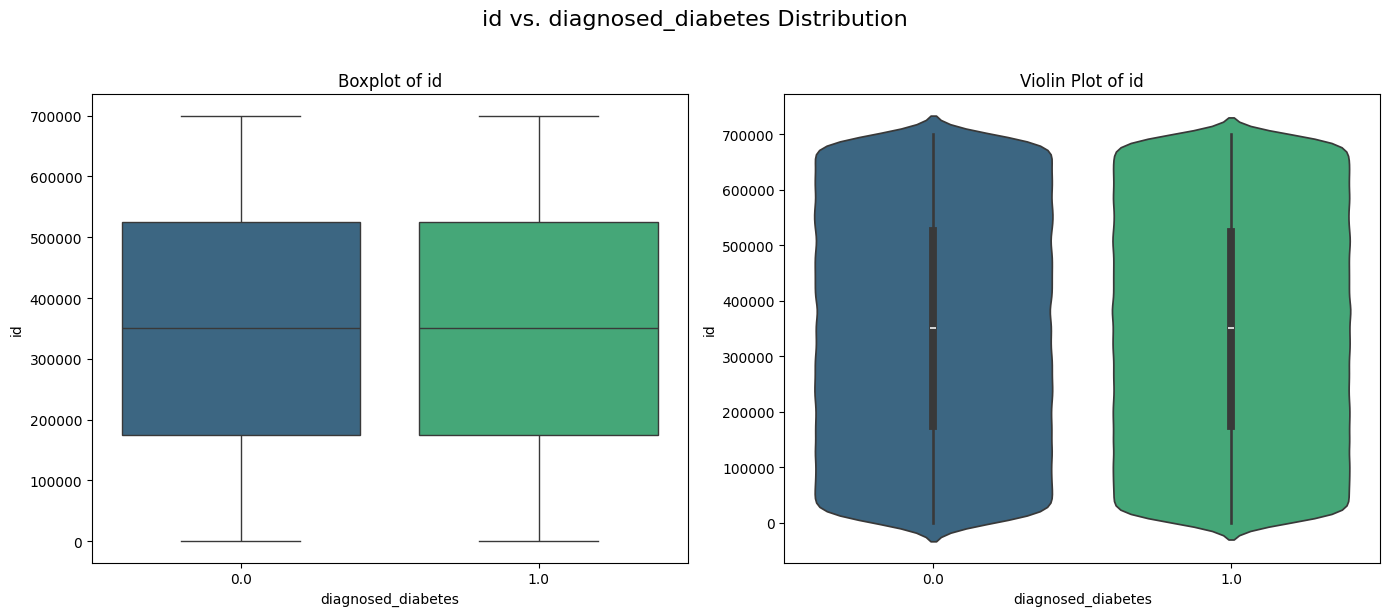

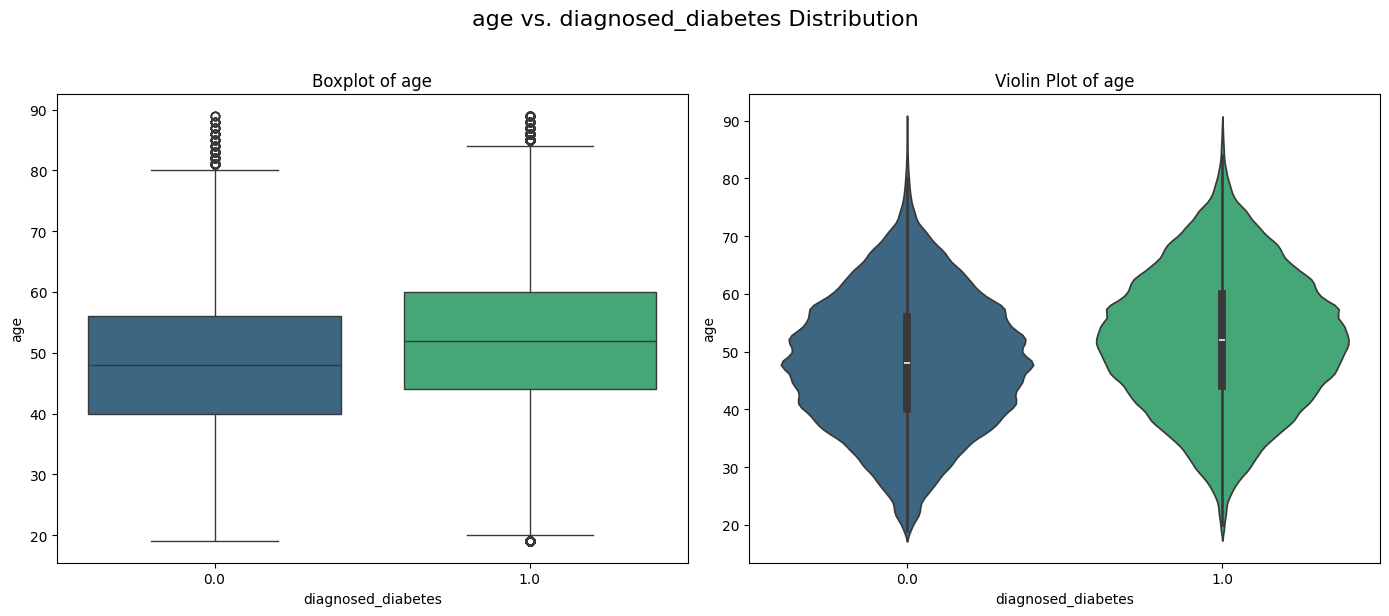

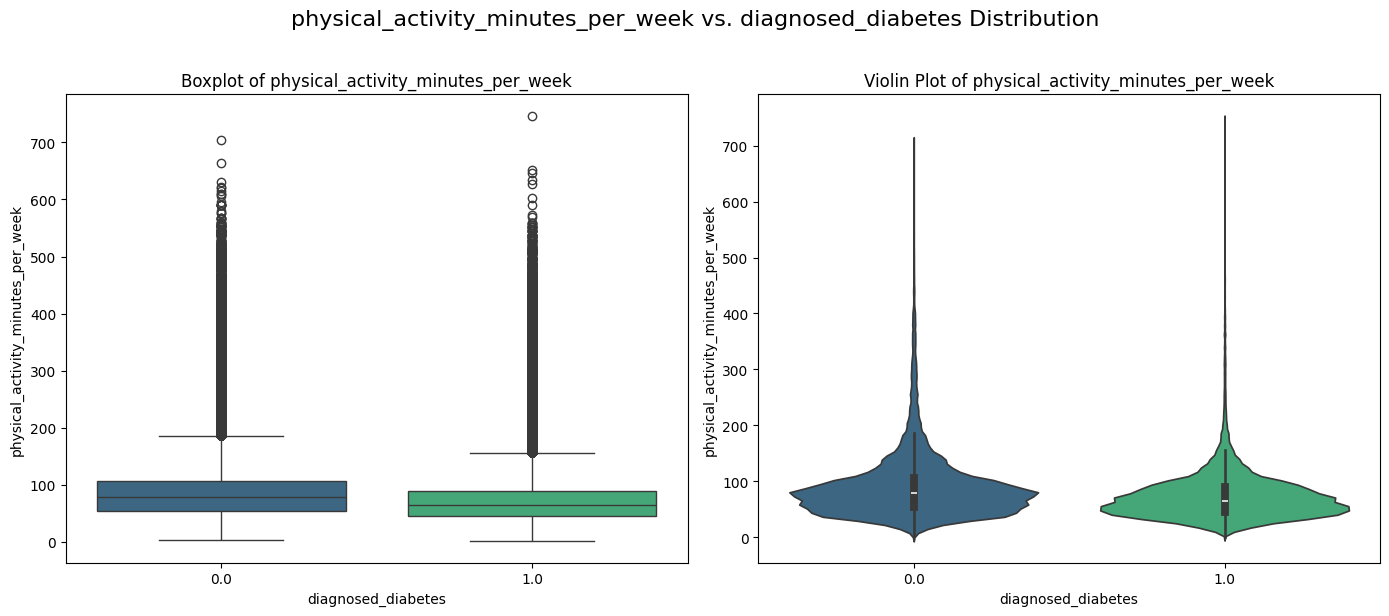

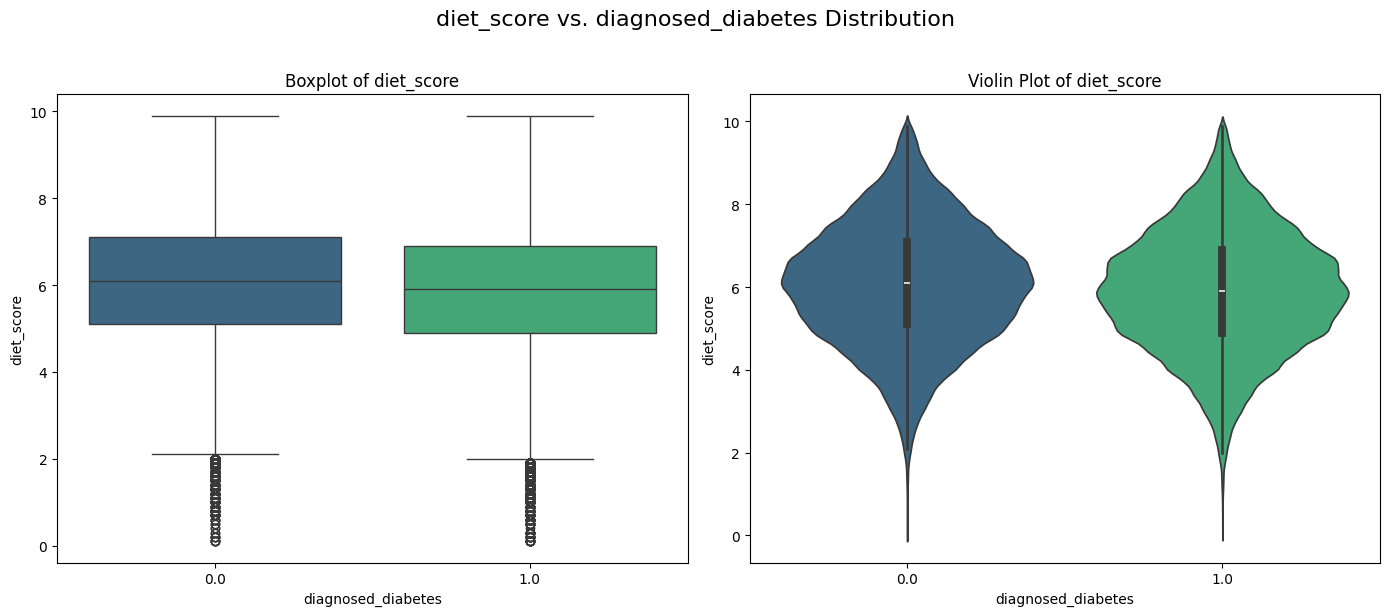

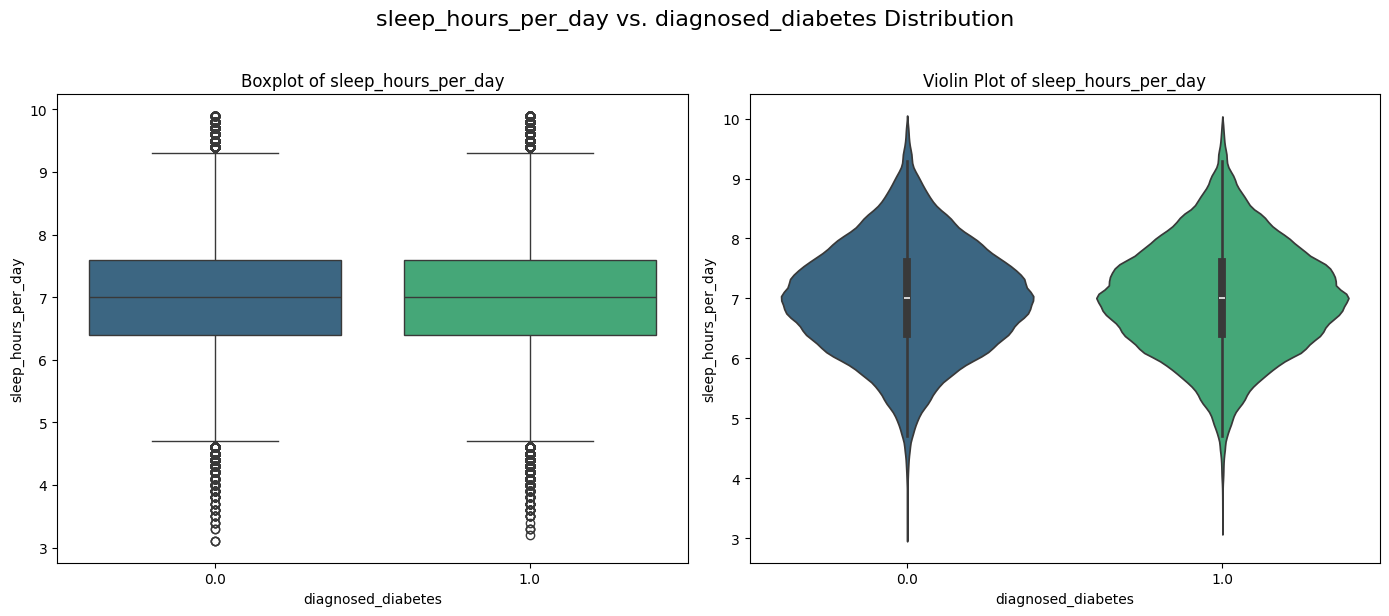

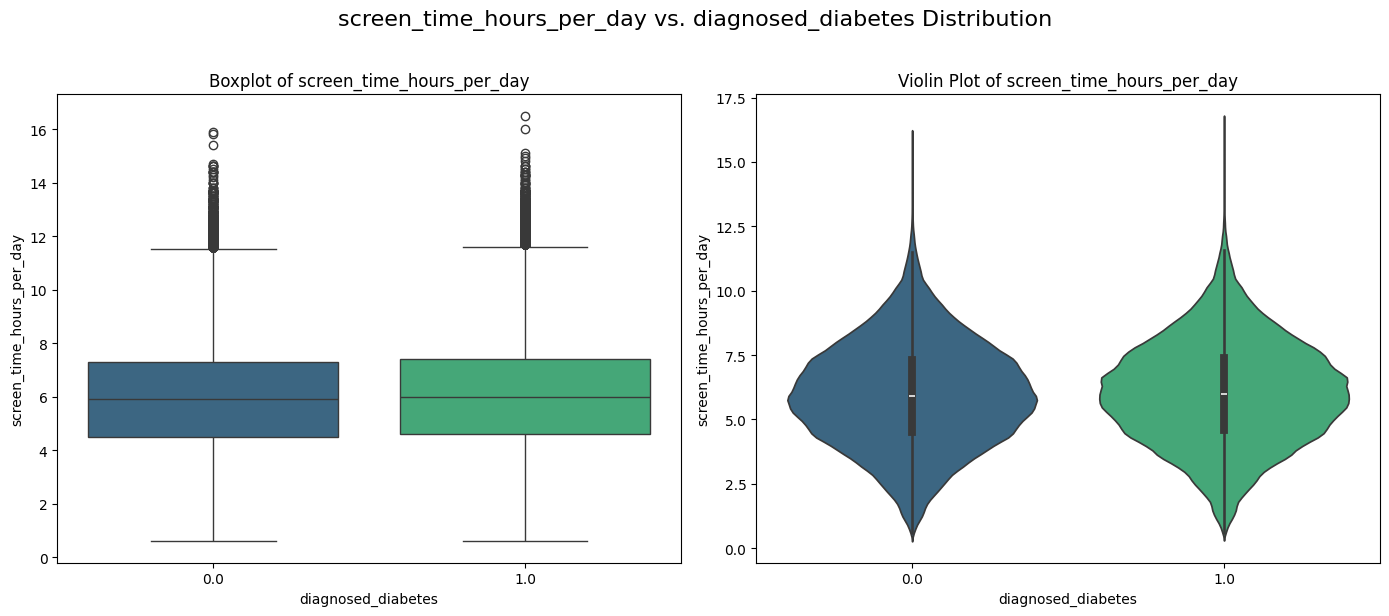

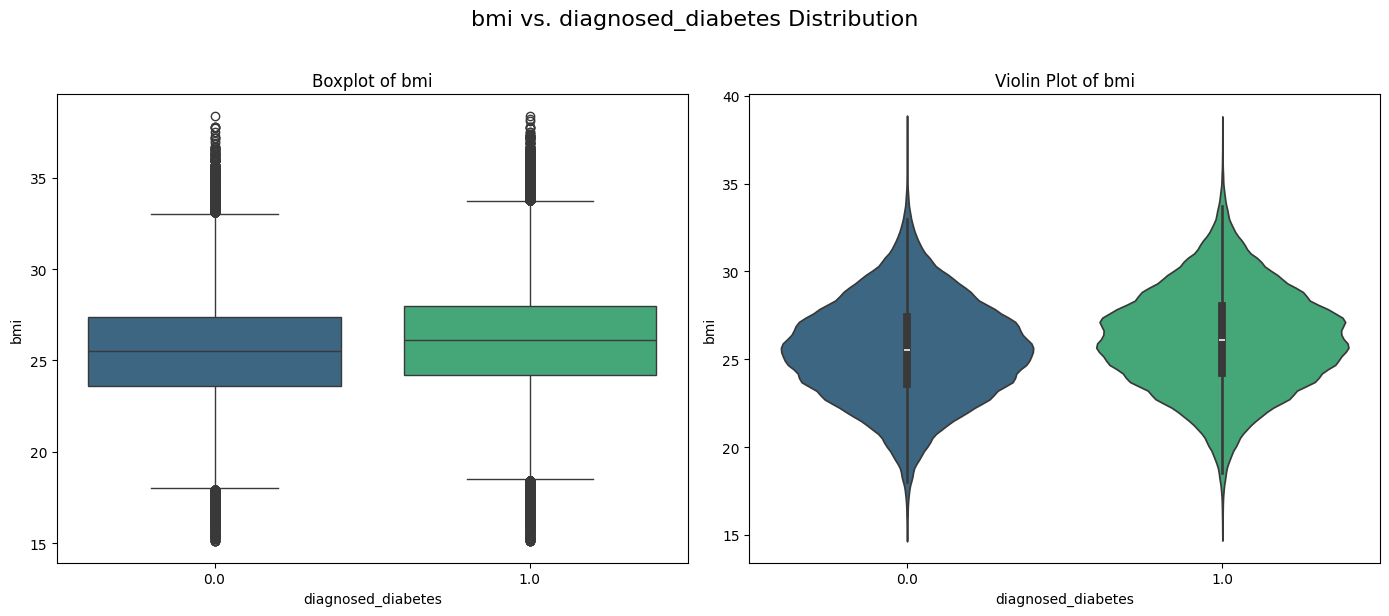

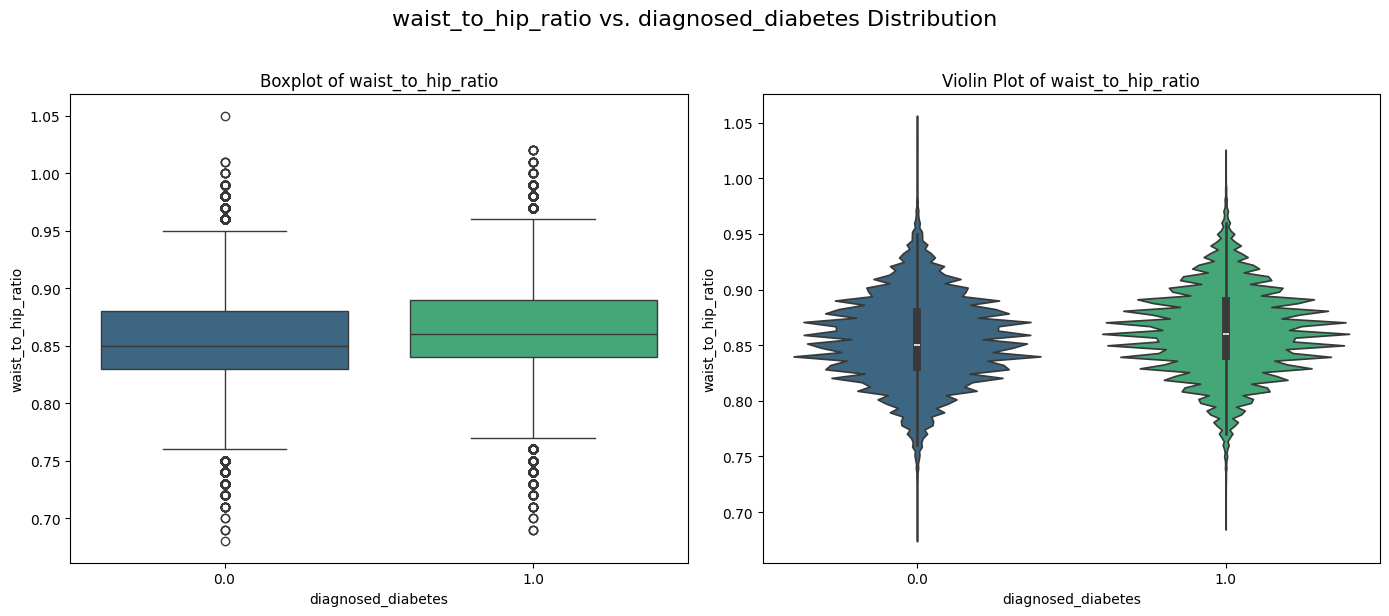

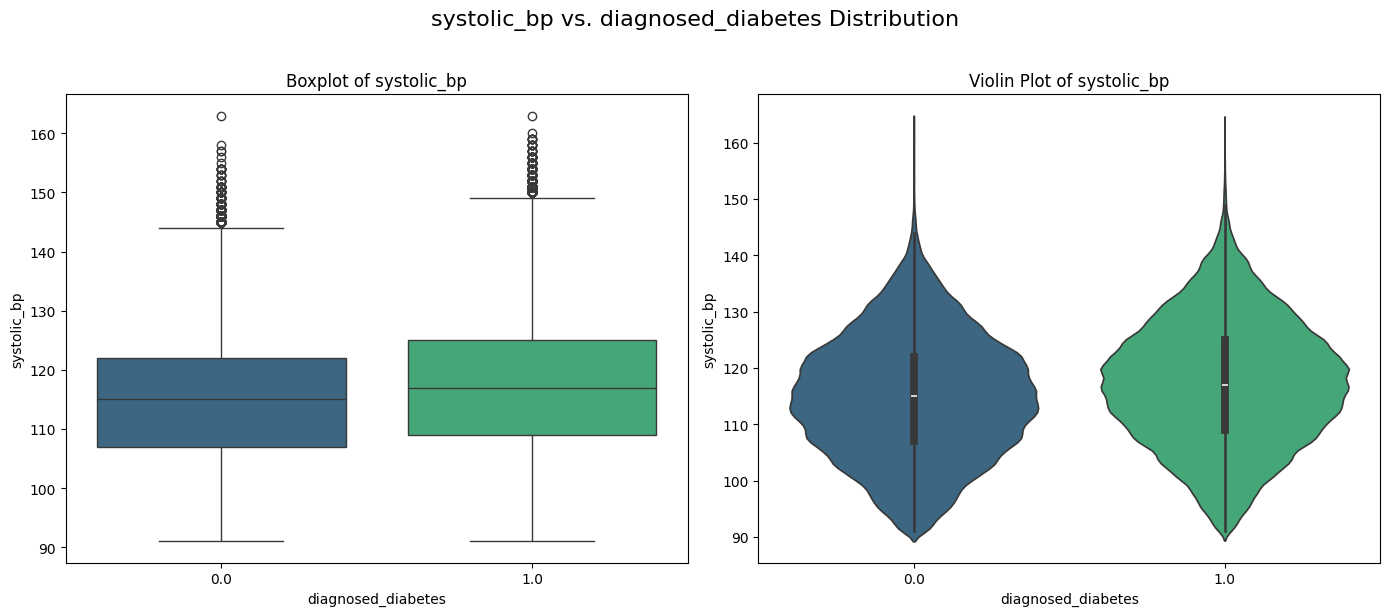

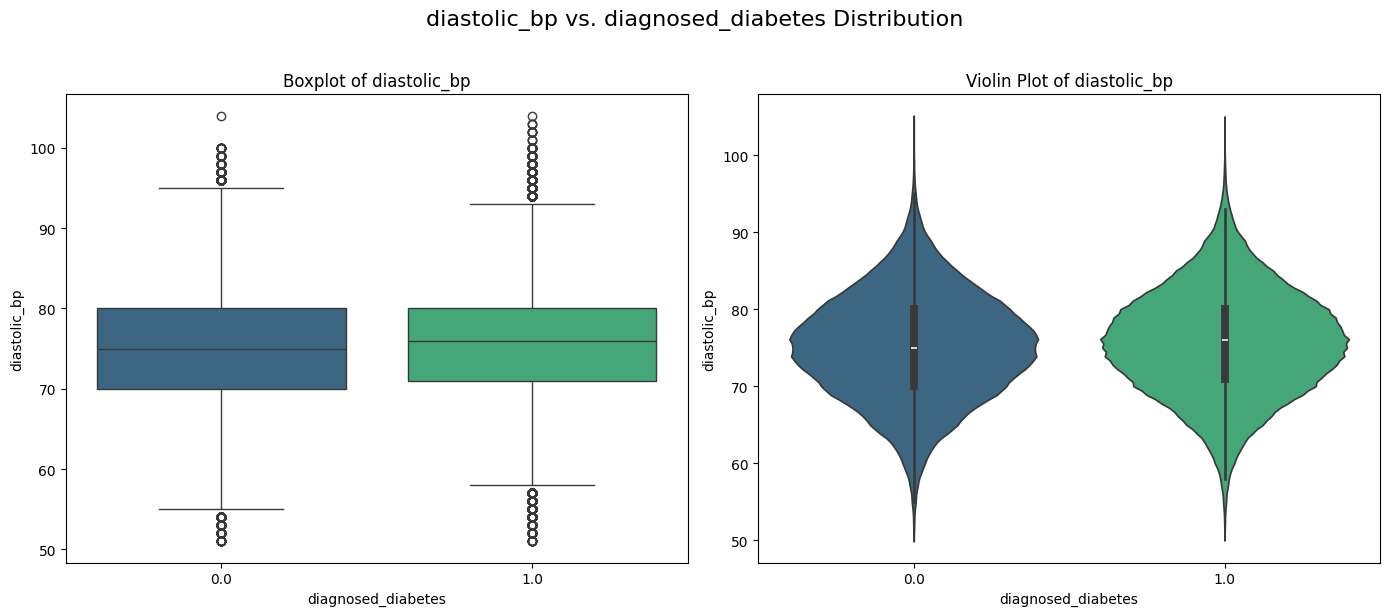

### Feature Signal Ranking

Top numeric (|Spearman|): [('family_history_diabetes', 0.211064155414004), ('physical_activity_minutes_per_week', -0.1629391129537935), ('age', 0.15463026488203255), ('systolic_bp', 0.10373513411926613), ('bmi', 0.10313995101384181), ('ldl_cholesterol', 0.09907236620664103), ('triglycerides', 0.08969700693425767), ('cholesterol_total', 0.0836832491911264), ('waist_to_hip_ratio', 0.07983955518195304), ('hdl_cholesterol', -0.05272681750938957)]
Top categorical (range of mean risk): [('ethnicity', 0.019621930235291796, 5), ('education_level', 0.01941857846650641, 4), ('gender', 0.018360187730334765, 3), ('income_level', 0.01003623952224686, 5), ('employment_status', 0.0065845482569989455, 4), ('smoking_status', 0.0024206920646833163, 3)]


In [26]:
run_data_visualization(training_df, target = TARGET, cat_count = 0)

## Findings from Data Visualizations

Our comprehensive EDA, driven by `ydata_profiling` and comparative distribution analysis, has provided critical insights that will dictate our downstream modeling strategy.

*    **Critical Distributional Shifts (Train vs. Test):** Unlike typical datasets where train and test distributions match perfectly, our comparative report flagged significant anomalies. Specifically, `screen_time_hours_per_day` appears effectively discrete or standardized in the Test set, while exhibiting a continuous distribution in the Training set. Similar patterns were observed in `systolic_bp` and cholesterol-related features. This suggests a potential **covariate shift** that must be addressed via adversarial validation or robust normalization to prevent overfitting to the training distribution.

*    **Strong Physiological Predictors:** The feature signal ranking validates the dataset against medical intuition. `family_history_diabetes` is the strongest risk factor (correlation: 0.21), followed by `age` and `bmi`. Crucially, the analysis correctly identifies `physical_activity` (-0.16) and `hdl_cholesterol` (-0.05) as protective factors (negative correlation), confirming the model can learn valid biological relationships.

*    **Multicollinearity Clusters:** We identified expected high correlations between physiological features, specifically `cholesterol_total` vs. `ldl_cholesterol` and `bmi` vs. `waist_to_hip_ratio`. While tree-based models (like LightGBM) are generally robust to collinearity, we may consider feature interaction or selection strategies to reduce noise.

*    **High Data Completeness:** The dataset exhibits high integrity with no significant missing values requiring complex imputation strategies. This allows us to focus our preprocessing efforts on encoding and handling the distributional skew mentioned above rather than data cleaning.

*    **Target Class Dynamics:** The target variable, `diagnosed_diabetes`, is binary. While we are treating this as a classification problem, the presence of specific risk clusters (high BMI, older age) suggests distinct decision boundaries. Evaluation will prioritize **AUC-ROC** to ensure the model correctly ranks probabilities rather than just predicting class labels.